# Experiment 11: Linear SVM Classification on the Iris Dataset
## Aim
Implement a Linear Support Vector Machine (SVM) to classify the Iris dataset (Setosa vs. Non-Setosa). Visualize the decision boundary and margin, and discuss how the margin is determined.

## Theory
A **Support Vector Machine (SVM)** is a classifier that finds the **hyperplane** (a straight line in 2D, a flat plane in 3D, and so on in higher dimensions) that best separates two classes. "Best" has a very specific meaning for SVM: among all the hyperplanes that correctly separate the classes, SVM picks the one that **maximizes the margin** — the distance between the hyperplane and the closest data point(s) from either class.

**Key vocabulary:**
- **Hyperplane / decision boundary**: `w·x + b = 0` — the line the classifier uses to split the two classes.
- **Margin**: the width of the empty "street" between the two classes, centered on the decision boundary. For a linear SVM the margin's half-width is `1 / ||w||`, so a smaller weight vector norm means a wider margin.
- **Support vectors**: the specific training points that lie exactly on the edge of the margin (the closest points to the boundary). These are the *only* points that determine where the boundary sits — every other point could be moved or removed without changing the boundary at all, which is why they are called "support" vectors: they alone support/define the solution.
- **Hard margin vs. soft margin**: a *hard* margin requires every point to be correctly classified and outside the margin — only possible if the classes are perfectly linearly separable. A *soft* margin (used by default in scikit-learn via the regularization parameter `C`) allows some points to violate the margin or even be misclassified, in exchange for a wider, more generalizable margin.

**Why maximizing the margin matters**: a boundary that squeezes as close as possible to the training points of both classes (a narrow margin) is more sensitive to noise and small shifts in new data — a new point only slightly different from a training point could easily fall on the wrong side. A wide margin leaves more "breathing room," making the classifier more robust and generally better at generalizing to unseen data. This is the central idea behind SVM: it isn't just looking for *any* separating line, it's looking for the one with the most robust buffer on both sides.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## Load and Explore the Iris Dataset

In [2]:
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['species']=pd.Categorical.from_codes(iris.target,iris.target_names)

print(df.shape)
df.head()

(150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


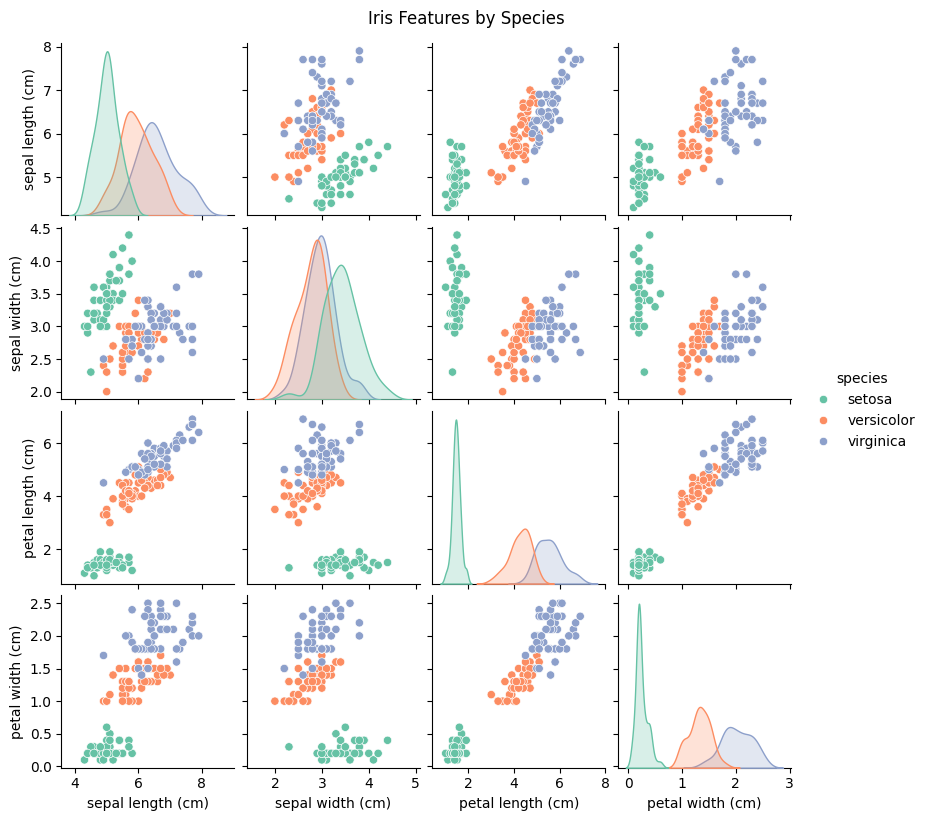

In [4]:
sns.pairplot(df,hue='species',vars=iris.feature_names,palette='Set2',height=2)
plt.suptitle('Iris Features by Species',y=1.02)
plt.show()

## Preprocess the Dataset
The task asks for **binary classification: Setosa vs. Non-Setosa**, so the 3-class target is converted into a binary label (`1` = Setosa, `0` = Versicolor or Virginica). Because SVM is a **margin/distance-based** algorithm, feature scaling matters a great deal: unscaled features with different numeric ranges would distort distance calculations and bias the margin toward whichever feature happens to have the largest raw scale. All four features are standardized (zero mean, unit variance) with `StandardScaler`.

In [5]:
X=iris.data
y=(iris.target==0).astype(int)

print('Class balance (1 = Setosa):')
print(pd.Series(y).value_counts())

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Class balance (1 = Setosa):
0    100
1     50
Name: count, dtype: int64


## Implement the Linear SVM (All 4 Features)

In [6]:
svm_full=SVC(kernel='linear',C=1.0)
svm_full.fit(X_train_scaled,y_train)
y_pred=svm_full.predict(X_test_scaled)

print('Accuracy :',accuracy_score(y_test,y_pred))
print('Precision:',precision_score(y_test,y_pred))
print('Recall   :',recall_score(y_test,y_pred))
print('F1-score :',f1_score(y_test,y_pred))
print('Number of support vectors (per class):',svm_full.n_support_)
print()
print(classification_report(y_test,y_pred))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
Number of support vectors (per class): [2 1]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Setosa turns out to be **perfectly linearly separable** from the other two species using these features — the model achieves perfect accuracy on the held-out test set, using only a handful of support vectors. This is a well-known property of the Iris dataset and makes it an ideal, clean example for visualizing exactly how a maximum-margin boundary looks.

## Visualize the Decision Boundary and Margin
A margin can only be drawn on a 2D plot, but the model above uses all 4 features. To visualize the boundary directly, a **second SVM is trained using only 2 features** — Petal Length and Petal Width, the two most visually separable features for Setosa — purely for plotting purposes. This is a standard technique: the full-feature model above is what should actually be used for real predictions, while the 2-feature model below exists only to make the margin visible.

In [7]:
X_2d=iris.data[:,[2,3]]
feature_names_2d=[iris.feature_names[2],iris.feature_names[3]]

scaler_2d=StandardScaler()
X_2d_scaled=scaler_2d.fit_transform(X_2d)

svm_2d=SVC(kernel='linear',C=1.0)
svm_2d.fit(X_2d_scaled,y)

print('Support vectors:',svm_2d.support_vectors_.shape[0])
print('Margin half-width (1/||w||):',1/np.linalg.norm(svm_2d.coef_))

Support vectors: 5
Margin half-width (1/||w||): 0.5592181958162422


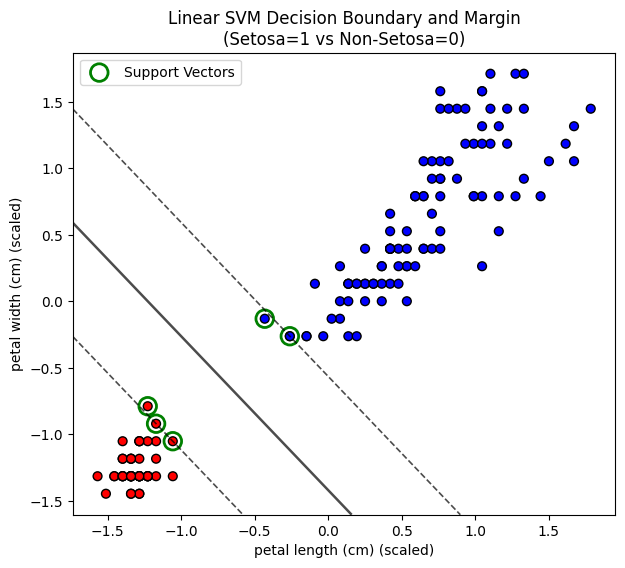

In [8]:
def plot_svm_boundary(model,X,y,ax,title):
    ax.scatter(X[:,0],X[:,1],c=y,cmap='bwr',edgecolors='k',s=40)
    xlim=ax.get_xlim()
    ylim=ax.get_ylim()
    xx=np.linspace(xlim[0],xlim[1],200)
    yy=np.linspace(ylim[0],ylim[1],200)
    YY,XX=np.meshgrid(yy,xx)
    xy=np.vstack([XX.ravel(),YY.ravel()]).T
    Z=model.decision_function(xy).reshape(XX.shape)
    ax.contour(XX,YY,Z,colors='k',levels=[-1,0,1],alpha=0.7,linestyles=['--','-','--'],linewidths=[1.2,1.8,1.2])
    ax.scatter(model.support_vectors_[:,0],model.support_vectors_[:,1],
               s=160,facecolors='none',edgecolors='green',linewidths=2,label='Support Vectors')
    ax.set_xlabel(feature_names_2d[0]+' (scaled)')
    ax.set_ylabel(feature_names_2d[1]+' (scaled)')
    ax.set_title(title)
    ax.legend()

fig,ax=plt.subplots(figsize=(7,6))
plot_svm_boundary(svm_2d,X_2d_scaled,y,ax,'Linear SVM Decision Boundary and Margin\n(Setosa=1 vs Non-Setosa=0)')
plt.show()

The **solid black line** is the decision boundary (`w·x + b = 0`). The two **dashed lines** on either side mark the edges of the margin (`w·x + b = ±1`) — the widest empty corridor that can be fit between the two classes. The **green-circled points** are the support vectors: the only training points that touch the margin edges. Notice that every other point sits safely outside the margin and plays no role in positioning the boundary — moving or deleting a non-support-vector point would not change this line at all.

## How the Regularization Parameter C Affects the Margin
`C` controls the **soft margin** tradeoff: a **small C** prioritizes a wide margin even if it means tolerating some margin violations, while a **large C** prioritizes classifying every training point correctly, even if that forces a narrower margin. Since Setosa is perfectly separable here, the effect is subtle on accuracy but still clearly visible in the margin width and the number of support vectors.

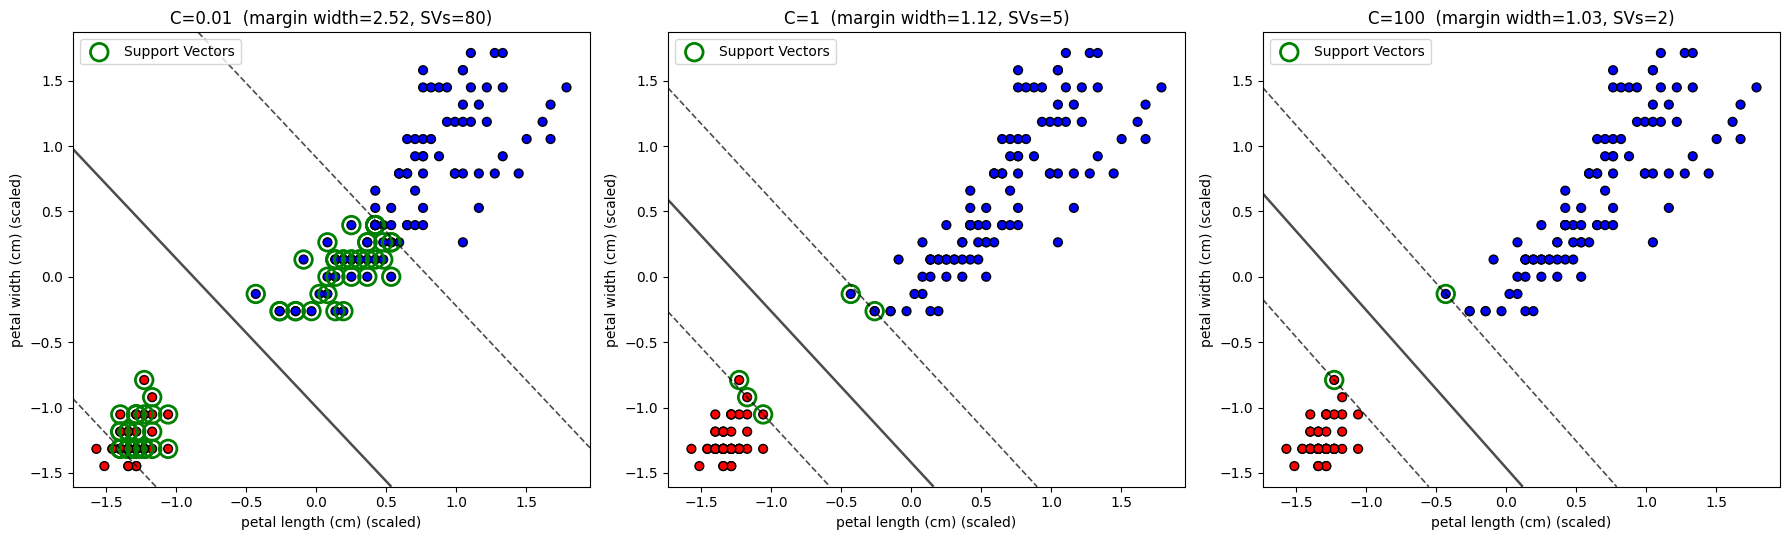

In [9]:
fig,axes=plt.subplots(1,3,figsize=(18,5.5))
C_values=[0.01,1,100]

for ax,C in zip(axes,C_values):
    model=SVC(kernel='linear',C=C)
    model.fit(X_2d_scaled,y)
    margin_width=2/np.linalg.norm(model.coef_)
    plot_svm_boundary(model,X_2d_scaled,y,ax,f'C={C}  (margin width={margin_width:.2f}, SVs={model.support_vectors_.shape[0]})')

plt.tight_layout()
plt.show()

## Confusion Matrix (Full 4-Feature Model)

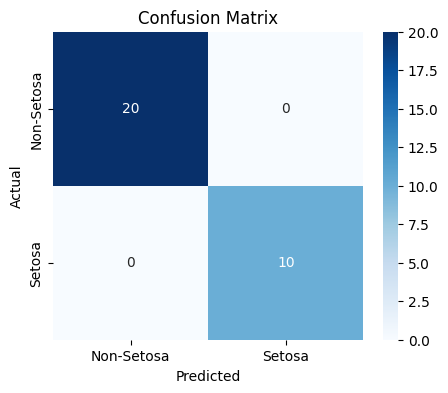

In [10]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Non-Setosa','Setosa'],yticklabels=['Non-Setosa','Setosa'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Discussion — How the Margin Is Determined
The margin is determined **entirely by the support vectors**, not by the full training set. Mathematically, for a linear SVM the decision boundary is `w·x + b = 0`, and the margin's half-width is `1 / ||w||`. Training the SVM is an optimization problem that **minimizes `||w||`** (equivalently, maximizes `1/||w||`, the margin) subject to every training point being correctly classified (hard margin) or correctly classified up to some allowed slack (soft margin, controlled by `C`). The optimizer only needs to satisfy this constraint for the points closest to the boundary — once those points (the support vectors) are correctly placed with the maximum possible margin, every other point further from the boundary is automatically satisfied too, which is exactly why only a small handful of points end up mattering.

The `C` sweep above makes the tradeoff concrete: a **small `C` (0.01)** produces the widest margin, accepting more support vectors (more points are allowed to sit closer to or even inside the margin) in exchange for a boundary that generalizes more cautiously. A **large `C` (100)** shrinks the margin and reduces the number of support vectors, fitting the training data more tightly — each point is pushed to matter less unless it's genuinely hard to classify, at the cost of a thinner safety buffer around the boundary. Since Setosa is perfectly linearly separable from the other two species on these features, all three settings still achieve perfect separation — but the **width of the margin and the identity of the support vectors clearly change**, which is the core mechanism `C` controls.

## Conclusion
A Linear SVM was trained to classify Setosa vs. Non-Setosa irises, achieving perfect separation thanks to the strong linear separability of this species on the given features. Visualizing the decision boundary with a 2-feature model showed the margin directly: the solid decision boundary, the dashed margin edges, and the support vectors that alone determine where that boundary sits. Sweeping the regularization parameter `C` confirmed that the margin's width is a direct, tunable consequence of how strictly the optimizer is required to fit every training point — a smaller `C` favors a wider, more robust margin, while a larger `C` favors a tighter fit to the training data at the cost of margin width.